# Classifying deconvolved calcium with a 3-state state-space model

This notebook mirrors the sorted-spikes classification tutorial, but uses OASIS-deconvolved calcium events at 30 Hz.

The classifier uses three discrete states:

1. **Local**: smooth position evolution (`RandomWalk`)
2. **Stationary**: position stays in one bin (`Identity`)
3. **Jump**: non-local transitions (`Uniform`)

The executable workflow in this notebook stays on the KDE path (`SortedSpikesClassifier` fed with deconvolved spikes). Package-level `CalciumClassifier` support for gamma and ZIG likelihoods is implemented separately.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from replay_trajectory_classification import (
    DiagonalDiscrete,
    Environment,
    Identity,
    RandomWalk,
    SortedSpikesClassifier,
    Uniform,
)
from replay_trajectory_classification.calcium_sorted_spikes_decoding import (
    deconvolve_and_binarize,
)
from replay_trajectory_classification.simulate_calcium import (
    make_continuous_replay,
    make_fragmented_replay,
    make_hover_replay,
    make_simulated_run_data,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_context("talk", font_scale=0.8)
np.random.seed(0)

Cupy is not installed or GPU is not detected. Ignore this message if not using GPU
I0000 00:00:1778655967.493123 1026177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778655967.520667 1026177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term


I0000 00:00:1778655968.095370 1026177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/multiunit_likelihood.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


In [2]:
TRACK_HEIGHT = 200.0
N_NEURONS = 20
PLACE_FIELD_MEANS = np.linspace(0.0, TRACK_HEIGHT, N_NEURONS)
SAMPLING_FREQUENCY = 30
INTERNAL_SAMPLING_FREQUENCY = 1000
RUNNING_SPEED = 15.0
SIGMA = 1.0
N_RUNS = 2
STATE_NAMES = ["Local", "Stationary", "Jump"]
PLACE_BIN_SIZE = 1.0

# Tunable event parameters at 30 Hz calcium timescale
CONTINUOUS_REPLAY_SPEEDUP = 1.0  # real-world speed; canonical replay is ~20x-120x faster
CONTINUOUS_N_FRAMES = 200  # frames for continuous event at calcium timescale
HOVER_N_FRAMES = 90  # frames for stationary/hover event
FRAGMENTED_N_FRAMES = 45  # frames for fragmented/jump event

## Simulate run data and fit the 3-state classifier

The key calcium-timescale adjustments are:

- The **discrete-state persistence** uses the default `DiagonalDiscrete(0.98)`, matching the sorted-spikes tutorial.
- The **local-motion prior** is estimated from the training run data via `estimate_movement_var()`, scaled by the 30 Hz sampling frequency — no replay speedup factor is applied because calcium imaging cannot resolve millisecond replay sequences.

In [3]:
from replay_trajectory_classification.continuous_state_transitions import (
    estimate_movement_var,
)


def make_run_dataset(seed):
    time, position, sampling_frequency, calcium_traces, true_spikes, _ = make_simulated_run_data(
        sampling_frequency=SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=RUNNING_SPEED,
        n_runs=N_RUNS,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=SIGMA,
        rng=np.random.default_rng(seed),
    )
    inferred_spikes = deconvolve_and_binarize(calcium_traces)
    return {
        "time": time,
        "position": position,
        "sampling_frequency": sampling_frequency,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "inferred_spikes": inferred_spikes,
    }


def make_classifier(movement_var):
    return SortedSpikesClassifier(
        environments=[Environment(environment_name="", place_bin_size=PLACE_BIN_SIZE)],
        continuous_transition_types=[
            [RandomWalk(movement_var=movement_var), Identity(), Uniform()],
            [RandomWalk(movement_var=movement_var), Identity(), Uniform()],
            [Uniform(), Uniform(), Uniform()],
        ],
        discrete_transition_type=DiagonalDiscrete(),
        sorted_spikes_algorithm="spiking_likelihood_kde",
        sorted_spikes_algorithm_params={
            "position_std": 3.0,
            "use_diffusion": False,
            "block_size": None,
        },
    )


def state_probability(results, posterior_name="acausal_posterior"):
    return getattr(results, posterior_name).sum("position")


def plot_state_probability(ax, results, posterior_name, title):
    posterior = state_probability(results, posterior_name)
    for state in posterior.state.values:
        ax.plot(posterior.time.values, posterior.sel(state=state).values, label=str(state), linewidth=2)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)


train = make_run_dataset(0)
test = make_run_dataset(1)

movement_var = float(estimate_movement_var(train["position"].reshape(-1, 1), SAMPLING_FREQUENCY))
print(f"Estimated movement variance: {movement_var:.3f} cm^2/frame")

classifier = make_classifier(movement_var)
classifier.fit(train["position"], train["inferred_spikes"])
run_results = classifier.predict(test["inferred_spikes"], time=test["time"], state_names=STATE_NAMES)

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


Estimated movement variance: 9.081 cm^2/frame


/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/20 [00:00<?, ?it/s]

/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/core.py:239: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  discrete_state_transition[state_k, state_k_1]


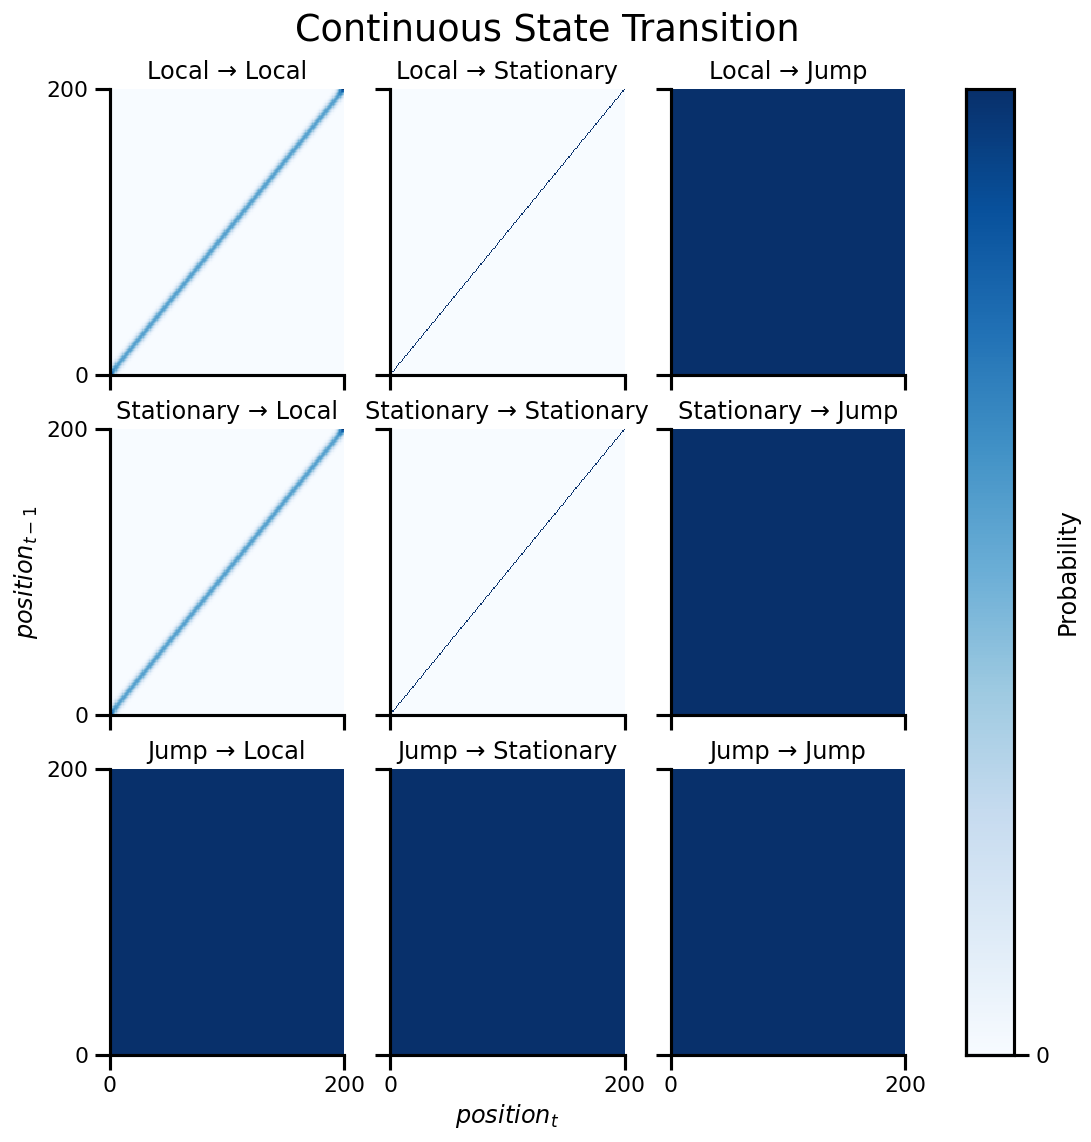

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9),
                         sharex=True, sharey=True,
                         constrained_layout=True)
x, y = np.meshgrid(classifier.environments[0].place_bin_edges_,
                   classifier.environments[0].place_bin_edges_)
state_names = STATE_NAMES
bin_min, bin_max = 0.0, TRACK_HEIGHT

for j in range(3):
    for k in range(3):
        im = axes[j, k].pcolormesh(
            x, y, classifier.continuous_state_transition_[j, k],
            cmap="Blues", vmin=0.0,
            vmax=classifier.continuous_state_transition_[j, k].max(),
        )
        axes[j, k].set_title(f"{state_names[j]} → {state_names[k]}")
        axes[j, k].set_xticks((bin_min, bin_max))
        axes[j, k].set_yticks((bin_min, bin_max))

plt.xlim((bin_min, bin_max))
plt.ylim((bin_min, bin_max))
axes[1, 0].set_ylabel(r"$position_{t-1}$")
axes[-1, 1].set_xlabel(r"$position_{t}$")
plt.suptitle("Continuous State Transition", y=1.04, fontsize=22)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=[0, 1], label="Probability")
cbar.ax.set_yticklabels(["0", "Max"])
sns.despine()

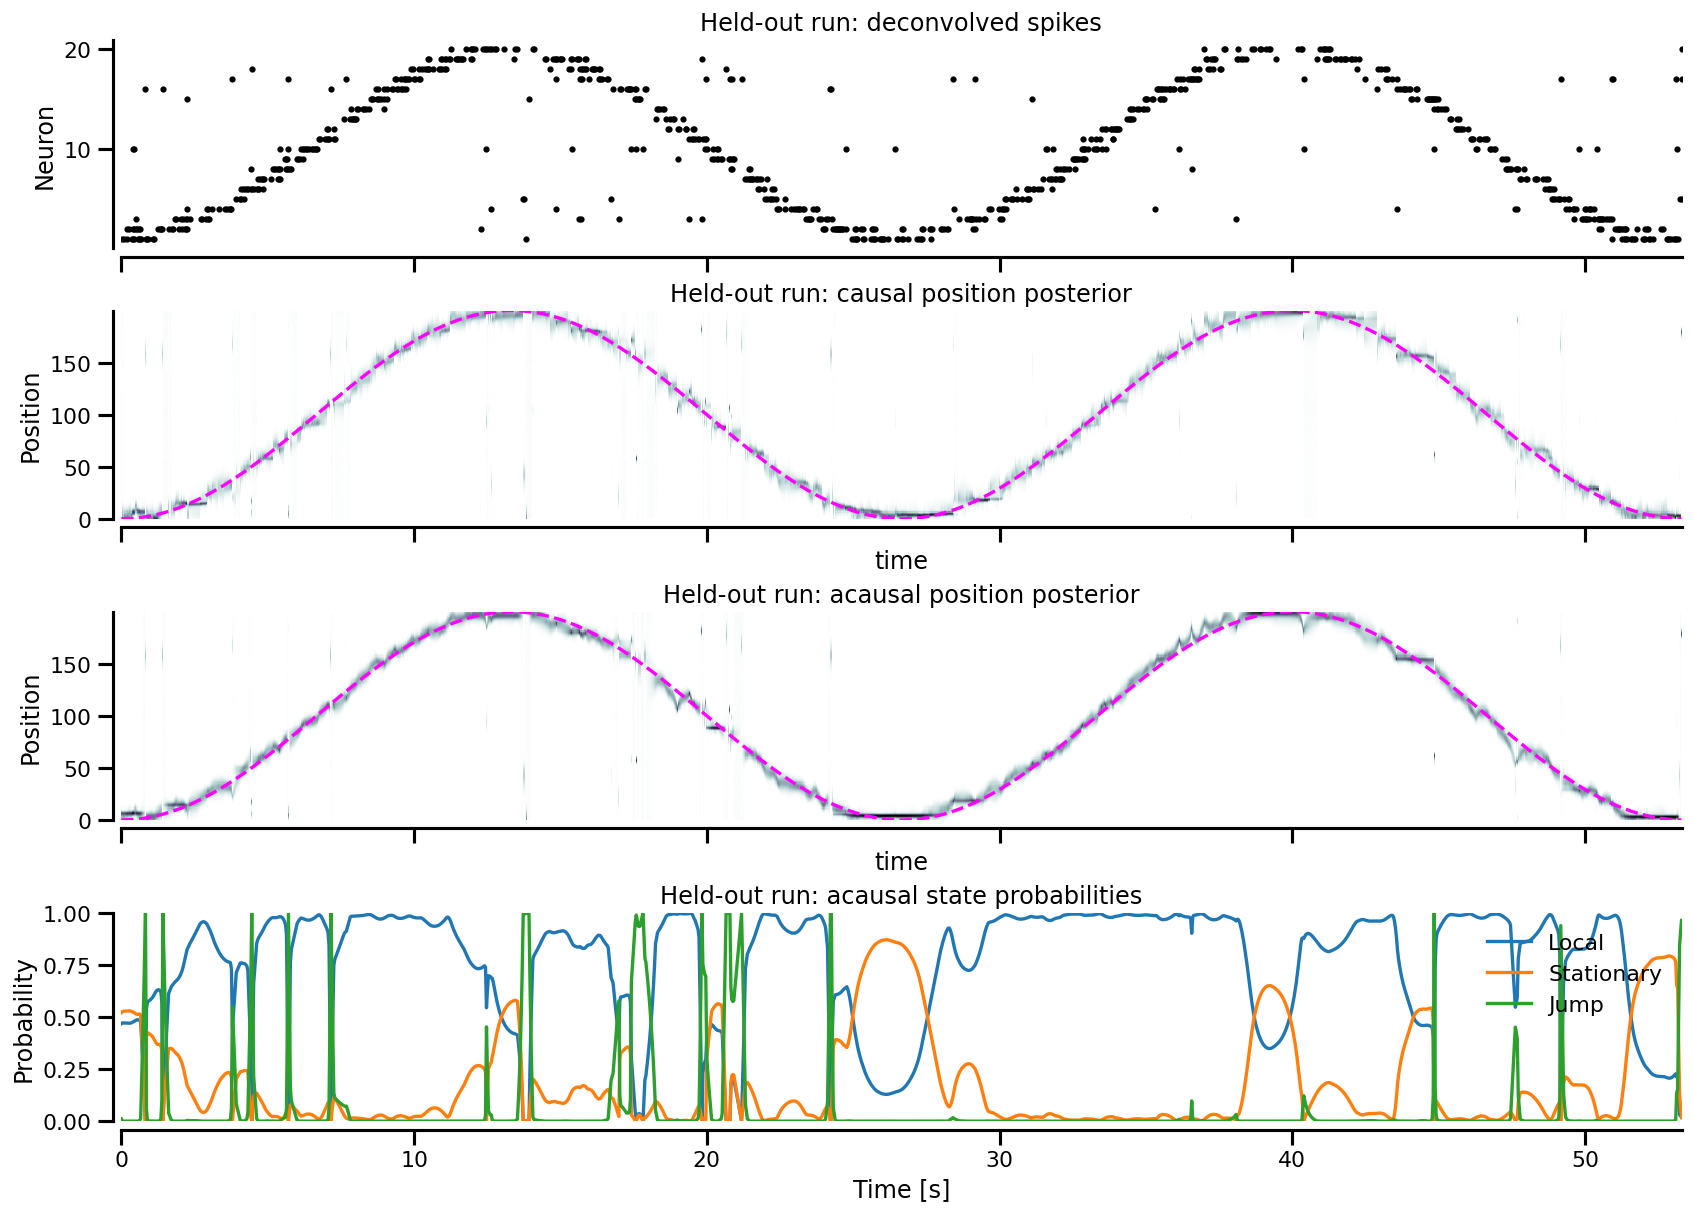

In [5]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(14, 10), constrained_layout=True)

spike_time_ind, neuron_ind = np.nonzero(test["inferred_spikes"])
axes[0].scatter(test["time"][spike_time_ind], neuron_ind + 1, s=5, color="black")
axes[0].set_ylabel("Neuron")
axes[0].set_title("Held-out run: deconvolved spikes")

run_results.causal_posterior.sum("state").plot(
    x="time", y="position", ax=axes[1], cmap="bone_r", add_colorbar=False
)
axes[1].plot(test["time"], test["position"], color="magenta", linestyle="--", linewidth=2)
axes[1].set_title("Held-out run: causal position posterior")
axes[1].set_ylabel("Position")

run_results.acausal_posterior.sum("state").plot(
    x="time", y="position", ax=axes[2], cmap="bone_r", add_colorbar=False
)
axes[2].plot(test["time"], test["position"], color="magenta", linestyle="--", linewidth=2)
axes[2].set_title("Held-out run: acausal position posterior")
axes[2].set_ylabel("Position")

plot_state_probability(axes[3], run_results, "acausal_posterior", "Held-out run: acausal state probabilities")
axes[3].set_xlabel("Time [s]")

sns.despine(offset=5)

## Classify continuous, stationary, and fragmented calcium events

The calcium simulation helpers now use durations that are meaningful at 30 Hz, so the events below span tens of frames rather than collapsing to 1-3 frames.

The event section now decodes from the same deconvolved-spike path as the run section (`inferred_spikes`), rather than from the ground-truth event spikes.

In [6]:
def make_event_dataset(name, event_fn, seed, **event_kwargs):
    time, true_spikes, calcium_traces = event_fn(
        sampling_frequency=SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=SIGMA,
        rng=np.random.default_rng(seed),
        **event_kwargs,
    )
    inferred_spikes = deconvolve_and_binarize(calcium_traces)
    results = classifier.predict(inferred_spikes, time=time, state_names=STATE_NAMES)
    return {
        "name": name,
        "time": time,
        "true_spikes": true_spikes,
        "calcium_traces": calcium_traces,
        "inferred_spikes": inferred_spikes,
        "results": results,
    }


event_datasets = [
    make_event_dataset("Continuous", make_continuous_replay, 2,
                       track_height=TRACK_HEIGHT, running_speed=RUNNING_SPEED,
                       n_frames=CONTINUOUS_N_FRAMES,
                       replay_speedup=CONTINUOUS_REPLAY_SPEEDUP),
    make_event_dataset("Stationary", make_hover_replay, 3,
                       n_frames=HOVER_N_FRAMES),
    make_event_dataset("Fragmented", make_fragmented_replay, 4,
                       n_frames=FRAGMENTED_N_FRAMES),
]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/20 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 90, using nperseg = 90
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/20 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 45, using nperseg = 45
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/20 [00:00<?, ?it/s]

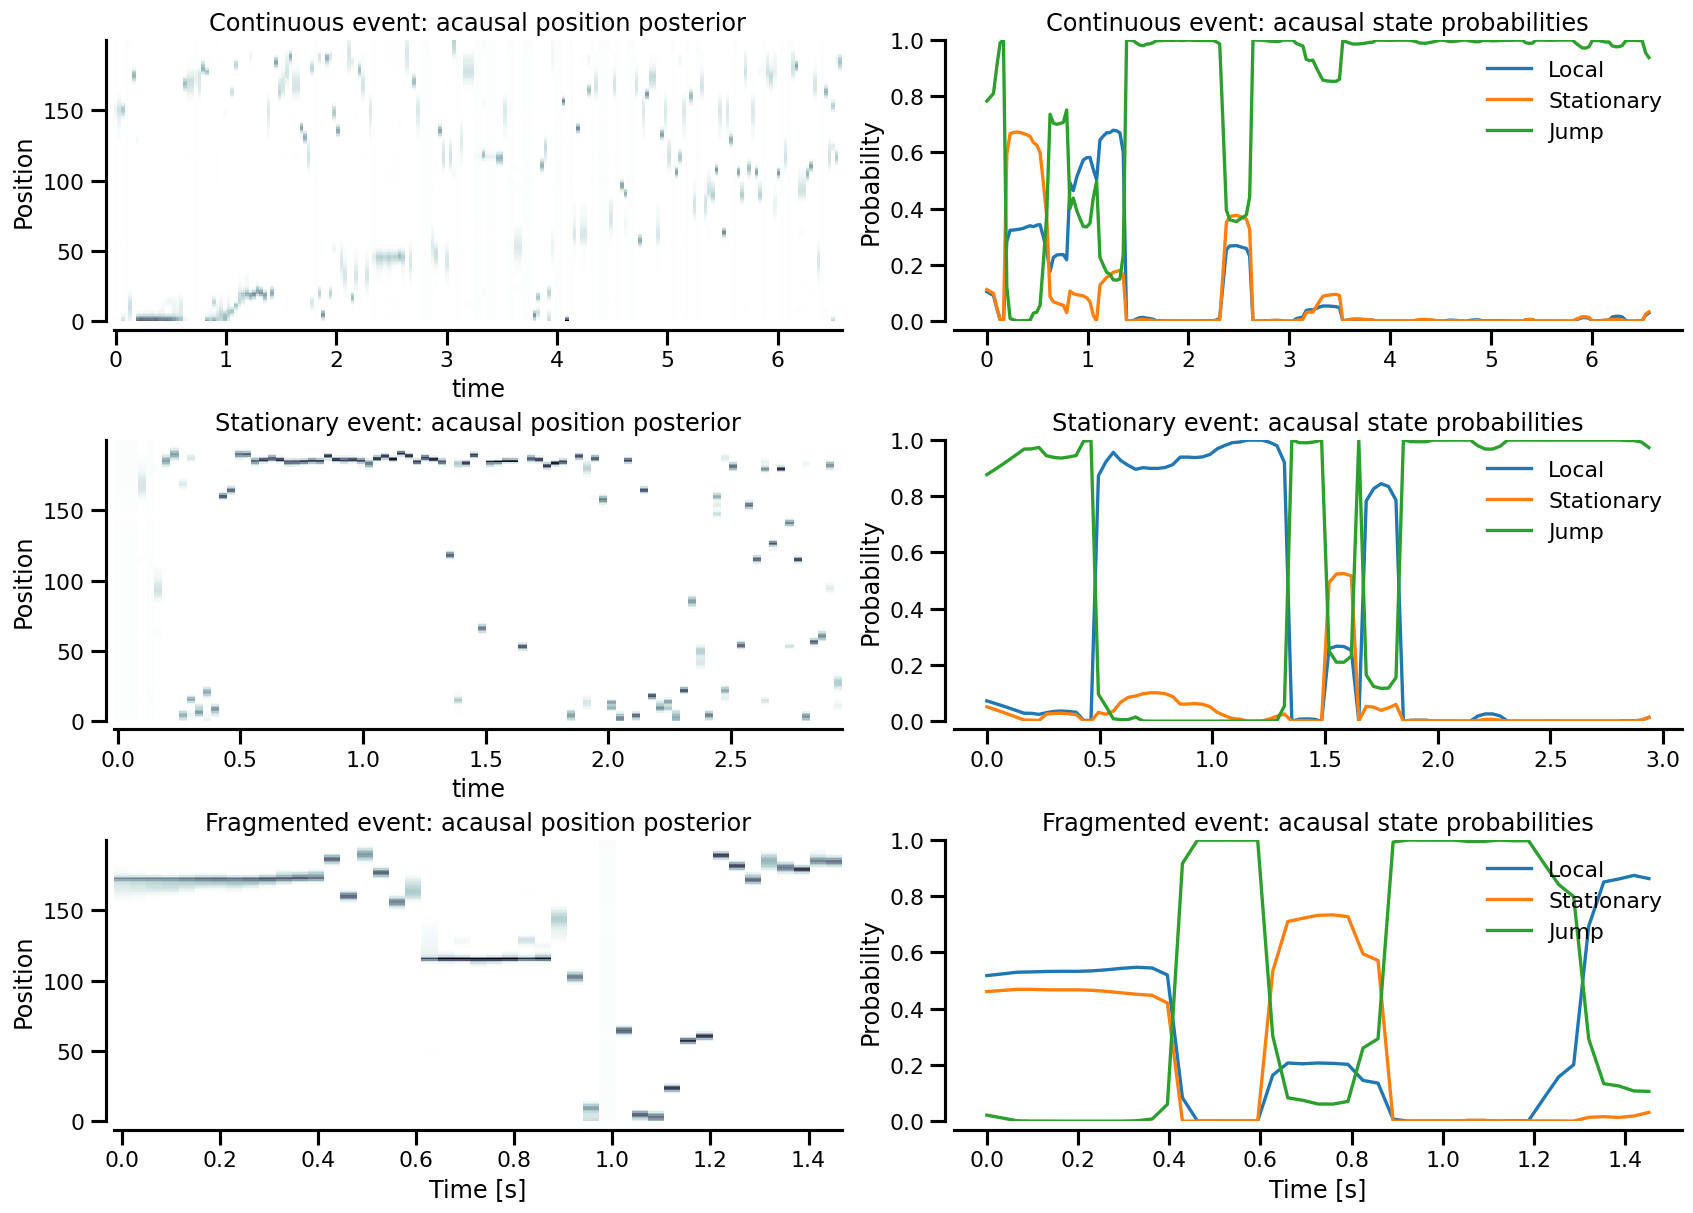

In [7]:
fig, axes = plt.subplots(len(event_datasets), 2, figsize=(14, 10), constrained_layout=True)

for row_ind, dataset in enumerate(event_datasets):
    dataset["results"].acausal_posterior.sum("state").plot(
        x="time", y="position", ax=axes[row_ind, 0], cmap="bone_r", add_colorbar=False
    )
    axes[row_ind, 0].set_title(f"{dataset['name']} event: acausal position posterior")
    axes[row_ind, 0].set_ylabel("Position")
    plot_state_probability(
        axes[row_ind, 1],
        dataset["results"],
        "acausal_posterior",
        f"{dataset['name']} event: acausal state probabilities",
    )

for ax in axes[-1, :]:
    ax.set_xlabel("Time [s]")

sns.despine(offset=5)

## Note on ZIG support

This notebook intentionally keeps the executable path on deconvolved spikes + KDE so the workflow stays close to the sorted-spikes tutorial.

The package now also exposes `CalciumClassifier`, which supports both:

- `calcium_likelihood` (gamma)
- `deconv_calcium_likelihood` (ZIG)

Those likelihood-specific classifier paths are covered in the package code and unit tests rather than executed here.